# Hybrid Quantum-Classical Reinforcement Learning (1/3)

___
___

## Introduction
___

This series of experiments is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- **Part I: Classical vs Qubit agents on the Cart Pole environment**
- [Part II: Classical vs Qubit agents on the Lunar Lander and Maze environments](QRL_experiment_2.ipynb)
- [Part III: Photonic agents on the three environments](QRL_experiment_3.ipynb)

This first notebook will present:
1. The Cart Pole environment
2. AutoEncoders (AEs)
3. Proximal Policy Optimization (PPO)
4. Classical PPO agent
5. Qubit-based PPO agent
6. Results
7. Conclusions
8. Follow-ups

*Note: This notebook was run on an Intel Core procesor i9-14900K (3.20 GHz) and an NVIDIA GeForce RTX 4090*


In [1]:
# Uncomment the following line to install the required dependencies
# !pip install ipynb torch torchvision gymnasium "gymnasium[classic-control]" matplotlib pennylane

In [2]:
import datetime
import random
import gc
import os
import time
import threading
import json
import psutil
from collections import namedtuple, deque
from itertools import count
import numpy as np
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import pennylane as qp

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Code works on both CPU and GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

# The results are saved in qrl_results/qrl_results.json
results_folder = "qrl_results"
os.makedirs(results_folder, exist_ok=True)
results_filename = "qrl_results.json"

## 1 - The Cart Pole environment
___

In the article mentioned in the introduction, the authors use two environments: CartPole-v1 (OpenAI Gymnasium) and Maze-v0 (custom environment). For this experiment to run in a short amount of time, we will use CartPole-v1 only.

But first, a small refresher on Reinforcement Learning: in this sub-field of Machine Learning, an agent interacts with an environment and learns a policy that maximizes its rewards.

<div align="center">
<img src="images/qrl_demo_rl.png" width="700"/>
</div>

At each moment, the state of the environment is observed and the agent chooses an action accordingly. This action changes the environment, which gives a reward (depending on how good that action was for the overall objective) and a new state. The agent must learn to choose the best actions depending on the environment's state, in order to maximize the cumulative reward.

___

In the Cart Pole environment, the agent must learn to balance a pole on top of a cart by moving the cart left and right. 

<div align="center">
<img src="images/qrl_demo_cartpole.gif" width="500"/>
</div>

At each step, the agent receives four observations: the cart's position, its velocity, the pole's angle and the pole's angular velocity. From these observations, it must then choose between two actions: push the cart to the left or push the cart to the right.

The agent receives a +1 reward for each step where the pole is considered balanced (pole's angle in the range of ±12°). The simulation (episode) ends when the pole is no longer balanced, when the cart's position is getting out of the display window or when the episode is > 500 steps.

More details about this environment can be found here: https://gymnasium.farama.org/environments/classic_control/cart_pole/.

In [3]:
# Create the Cart Pole environment with gymnasium
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)

42

## 2 - AutoEncoders (AEs)
___

The Cart Pole environment contains four observations which can be reduced to only two variables with an AE.

AEs are used for dimensionality reduction, data compression and feature learning. They are composed of an encoder which produces a compressed representation of the original data, and a decoder which reconstructs the original data from the compressed, latent space representation.

<div align="center">
<img src="images/qrl_demo_autoencoder.png" width="700"/>
</div>

This way, AEs learn to create a relevant low-dimensional latent space representation of the original data. This is useful for quantum computing as it reduces the amount of data nodes (qubits/qumodes) needed and therefore the overall computational cost.

Though AEs are usually trained in an unsupervised manner, learning to reconstruct the original data by themselves, the article's approach is different. Here, the authors choose to train the AE jointly with the PPO agents. This ensures that the latent space representation learned by the AE is specifically suited to this RL problem.

In [4]:
class EncoderDecoderNN(nn.Module):
    ''' The same model template can be used for both the Encoder and the Decoder.
        Their dimensions will simply be mirrors of each other '''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        return self.layer3(x)

class AutoEncoder(nn.Module):
    def __init__(self, input_shape, parameters):
        super().__init__()
        input_dim = input_shape[0]
        self.encoder = EncoderDecoderNN(input_dim, parameters["ae_hidden_dim"], parameters["ae_output_dim"])
        self.decoder = EncoderDecoderNN(parameters["ae_output_dim"], parameters["ae_hidden_dim"], input_dim)

## 3 - Proximal Policy Optimization (PPO)
___

The framework of Proximal Policy Optimization (PPO) involves two models: the Actor and the Critic. At each step, the Actor receives the compressed observations of the environment from the AE (the state representation) and outputs a probability distribution over the possible actions. An action is sampled from this distribution and executed in the environment.

The environment returns a reward for each action taken. The goal of PPO is to maximize the expected cumulative reward over an episode.

To achieve this, the Critic learns to associate each state with a value representing the expected cumulative future reward from that state. The Actor, meanwhile, learns a policy that assigns higher probabilities to actions that are expected to produce greater rewards.

<div align="center">
<img src="images/qrl_demo_classicalPPO.png" width="700"/>
</div>

To train both models, an advantage function is computed. It measures how much the observed returns based on the Actor's policy exceed the value predicted by the Critic for that state.

This advantage is then used to update both the Actor and the Critic. The Critic learns by minimizing the difference between its predicted state values and the observed returns collected during the episode.

The Actor is updated by comparing the probability of the actions under the current policy with the probability under the policy that originally generated those actions. This probability ratio is multiplied by the advantage, so actions that produced higher-than-expected rewards become more likely, while those with lower-than-expected rewards become less likely.

To prevent excessively large policy updates that would destabilize learning, PPO uses the clipped surrogate objective. This loss limits how much the probability ratio can deviate from its previous value, preventing overly aggressive updates. The Actor is gradually optimized through backpropagation, resulting in more stable learning.

Finally, a Rollout Buffer is used to store the collected experiences (state, action, reward, next state, and related quantities such as the action log probability and estimated value). The Actor and Critic repeatedly sample from this buffer during each PPO update before a new rollout is collected.

In [5]:
def count_parameters(model):
    ''' Counts the parameters in a model '''
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def load_results(results_filepath):
    ''' Loads the existing results, if any'''
    qrl_results = {}
    if os.path.exists(results_filepath):
        with open(results_filepath, "r") as fp:
            qrl_results = json.load(fp)
    return qrl_results

def save_results(results_filepath, env_name, results_type, results):
    ''' Saves / adds the results of the models per environment '''
    qrl_results = load_results(results_filepath)
    if env_name not in qrl_results:
        qrl_results[env_name] = {}
    qrl_results[env_name][results_type] = results
    with open(results_filepath, "w") as fp:
        json.dump(qrl_results, fp)
    return qrl_results

class RolloutBuffer:
    ''' Stores Experiences at each step for the models to learn on '''
    def __init__(self, size):
        self.memory = deque([], maxlen=size)
        self.Experience = namedtuple(
            'Experience',
            ('state', 'action', 'action_log_probability', 'state_value', 'reward', 'done')
            )

    def add(self, *args):
        self.memory.append(self.Experience(*args))

    def get(self):
        batch = self.Experience(*zip(*self.memory))
        states = torch.cat(batch.state)
        actions = torch.cat(batch.action)
        action_log_probabilities = torch.cat(batch.action_log_probability)
        state_values = torch.squeeze(torch.cat(batch.state_value), dim=-1)
        rewards = np.array(batch.reward)
        dones = np.array(batch.done)
        return states, actions, action_log_probabilities, state_values, rewards, dones

class PPO:
    ''' Implements PPO with an AutoEncoder compressing the observations '''
    def __init__(self, AutoEncoderClass, ActorClass, CriticClass, env, env_name, env_config, mode, device, results_folder, results_filename, memory_stats, custom_obs_shape=None):
        self.env = env
        self.env_name = env_name
        self.env_initials = "".join([s[0] for s in self.env_name.lower().split(" ")])
        self.config = env_config
        self.mode = mode
        self.device = device
        self.results_folder = results_folder
        self.results_filepath = os.path.join(self.results_folder, results_filename)
        self.memory_stats = memory_stats
        observations_shape = self.env.observation_space.shape
        if custom_obs_shape is not None:
            observations_shape = custom_obs_shape
        n_actions = self.env.action_space.n
        self.buffer = RolloutBuffer(self.env._max_episode_steps * self.config["episode_update_frequency"])
        self.autoencoder = AutoEncoderClass(observations_shape, self.config).to(self.device)
        self.actor = ActorClass(input_shape=self.config["ae_output_dim"], intermediate_dim=self.config["actor_intermediate_dim"], output_dim=n_actions, device=self.device).to(self.device)
        self.critic = CriticClass(input_shape=observations_shape, intermediate_dim=self.config["critic_intermediate_dim"], output_dim=1).to(self.device)
        self.optimizer = optim.Adam(list(self.autoencoder.parameters()) + list(self.actor.parameters()) + list(self.critic.parameters()), lr=self.config["lr"])
        self.n_parameters = count_parameters(self.actor)

    def run(self):
        print(f"\nPPO training")
        training_start = datetime.datetime.now()
        rewards = []
        mean_rewards = []
        mean_reward = 0
        total_episodes = 0
        optimization_start = datetime.datetime.now()

        # The training stops when the PPO has achieved a predetermined reward level
        while mean_reward < self.config["mean_reward_stop"]:
            # Episode starts
            state, _ = self.env.reset()
            cumulative_reward = 0
            for _ in count():

                # Calling the AE, the actor and the critic
                state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    encoded_state = F.tanh(self.autoencoder.encoder(state))
                    action, action_log_probability, _, state_value = self.apply_policy(state, encoded_state)

                # Applying the actor's action to the environment
                next_state, reward, terminated, truncated, _ = self.env.step(action.item())
                done = terminated or truncated

                # Saving data into the Rollout Buffer
                self.buffer.add(state.detach(), action.detach(), action_log_probability.detach(), state_value.detach(), reward, done)

                cumulative_reward += reward
                state = next_state
                
                if done:
                    # Episode ends
                    total_episodes += 1
                    break
            
            # Every few episodes, the models are optimized
            if total_episodes % self.config["episode_update_frequency"] == 0:
                self.optimize_models()

            # Every few episodes, the training results are printed
            if total_episodes % self.config["print_episodes_frequency"] == 0:
                print(f"\nEpisode {total_episodes}: mean reward = {mean_reward:.2f} ({datetime.datetime.now()-optimization_start})")
                optimization_start = datetime.datetime.now()

            # Saving the training results
            rewards.append(cumulative_reward)
            mean_reward = np.mean(rewards[-self.config["mean_reward_lookback"]:])
            mean_rewards.append(mean_reward)
            training_time = datetime.datetime.now()-training_start
            results = { 
                "training_time": training_time.total_seconds(), 
                "mean_rewards": mean_rewards, 
                "parameters": self.n_parameters, 
                "memory": self.memory_stats.peak_rss_mb 
            }
            qrl_results = save_results(self.results_filepath, self.env_name, self.mode, results)

        # End of training
        print(f"\nTotal training time: {training_time}")
        return qrl_results

    def apply_policy(self, state, encoded_state, action=None):
        # Get the action and the distribution's properties from the actor
        actions_probs = F.softmax(self.actor(encoded_state), dim=-1)
        actions_distribution = torch.distributions.Categorical(actions_probs)
        if action is None:
            action = actions_distribution.sample()
        action_log_probability = actions_distribution.log_prob(action)
        distribution_entropy = actions_distribution.entropy()
        # Get the state's value from the critic
        state_value = self.critic(state)
        return action, action_log_probability, distribution_entropy, state_value
    
    def optimize_models(self):
        # Retrieving the data from the Rollout Buffer
        states, actions, action_log_probabilities, state_values, rewards, dones = self.buffer.get()
        next_state_values = torch.cat([state_values[1:], torch.zeros(1, device=self.device)])

        # Calculating the advantage (expected returns) at each step of each episode
        advantages = []
        advantage = 0
        for reward, done, value, next_value in zip(
            reversed(rewards), reversed(dones), reversed(state_values), reversed(next_state_values)
        ):
            done_mask = 1.0 - done # Expected return from the last step of the episode is zero
            delta = reward + self.config["gamma"] * next_value * done_mask - value
            advantage = delta + self.config["gamma"] * self.config["lambda"] * done_mask * advantage
            advantages.insert(0, advantage)
        advantages = torch.stack(advantages)
        returns = advantages + state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-9)

        # The models will learn on minibatches of data
        mb_size = self.config["minibatch_size"]
        n = states.shape[0]
        for _ in range(self.config["K"]):
            rnd_permutations = torch.randperm(n, device=self.device)

            for start in range(0, n, mb_size):
                idx = rnd_permutations[start:start + mb_size]

                mb_states = states[idx]
                mb_actions = actions[idx]
                mb_old_log_probs = action_log_probabilities[idx]
                mb_advantages = advantages[idx]
                mb_returns = returns[idx]

                # Apply the full AE to the states to get their reconstructions for computing the AE loss
                encoded_states = F.tanh(self.autoencoder.encoder(mb_states))
                reconstructed_states = self.autoencoder.decoder(encoded_states)
                
                # Get the results of the actor and critic under the current policy
                _, new_action_log_probabilities, entropy, new_state_values = self.apply_policy(mb_states, encoded_states, mb_actions)
                new_state_values = torch.squeeze(new_state_values, dim=1)
                
                # Calculate the objective
                policy_ratio = torch.exp(new_action_log_probabilities - mb_old_log_probs)
                objective = policy_ratio * mb_advantages
                clipped_objective = torch.clamp(
                    policy_ratio, min=1 - self.config["epsilon"], max=1 + self.config["epsilon"]
                ) * mb_advantages
                clipped_surrogate_loss = torch.min(objective, clipped_objective)

                # Compute the losses for the autoencoder, actor and critic
                ae_loss = F.mse_loss(reconstructed_states, mb_states).mean()
                policy_loss = -(clipped_surrogate_loss + self.config["entropy_coeff"] * entropy).mean()
                value_loss = F.mse_loss(new_state_values, mb_returns).mean()
                loss = ae_loss + policy_loss + 0.5 * value_loss

                # Backpropagation
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.autoencoder.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
                self.optimizer.step()
        
        # Save the optimized models
        torch.save(self.autoencoder.state_dict(), os.path.join(self.results_folder, f"{self.env_initials}_{self.mode}_ae.pt"))
        torch.save(self.actor.state_dict(), os.path.join(self.results_folder, f"{self.env_initials}_{self.mode}_actor.pt"))
        torch.save(self.critic.state_dict(), os.path.join(self.results_folder, f"{self.env_initials}_{self.mode}_critic.pt"))
        self.buffer.memory.clear()

    def evaluate(self):
        # Matplotlib is used to display an episode with the PPO in action
        fig, ax = plt.subplots()
        im = None

        # Episode starts
        state, _ = self.env.reset()
        for _ in count():

            # An action is sampled from the actor's policy
            state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
            with torch.no_grad():
                encoded_state = F.tanh(self.autoencoder.encoder(state))
                actions_probs = F.softmax(self.actor(encoded_state), dim=-1)
                actions_distribution = torch.distributions.Categorical(actions_probs)
                action = actions_distribution.sample()

            # The action is executed in the environment
            next_state, _, terminated, truncated, _ = self.env.step(action.item())
            done = terminated or truncated
            state = next_state

            # Render the environment
            frame = self.env.render()
            if im is None:
                im = ax.imshow(frame)
                ax.axis("off")
            else:
                im.set_data(frame)
            clear_output(wait=True)
            display(fig)

            if done:
                # Episode ends
                break
        
        # Close the maptlotlib figure
        clear_output(wait=True)
        plt.close(fig)

## 4 - Classical PPO agent
___

In the classical case of PPO, both the Actor and the Critic are simple Neural Networks (NNs).

In [6]:
class ActorNN(nn.Module):
    ''' A simple Neural Network for the Actor '''
    def __init__(self, input_shape, intermediate_dim, output_dim, device=None):
        super().__init__()
        if isinstance(input_shape, int):
            input_dim = input_shape
        else:
            input_dim = input_shape[0]
        self.layer1 = nn.Linear(input_dim, intermediate_dim)
        self.layer2 = nn.Linear(intermediate_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        return self.layer2(x)
    
class CriticNN(nn.Module):
    ''' A simple Neural Network for the Critic'''
    def __init__(self, input_shape, intermediate_dim, output_dim):
        super().__init__()
        if isinstance(input_shape, int):
            input_dim = input_shape
        else:
            input_dim = input_shape[0]
        self.layer1 = nn.Linear(input_dim, intermediate_dim)
        self.layer2 = nn.Linear(intermediate_dim, intermediate_dim)
        self.layer3 = nn.Linear(intermediate_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        return self.layer3(x)

## 5 - Qubit-based PPO agent
___

The quantum versions of PPO used in the article replace the Actor's NN by a Parametrized Quantum Circuit (PQC). In the case of the qubit-based PPO agent, the PQC consists of several layers of unitary operators. 

First, there is an encoding unitary for the latent representations of the AE, followed by several trainable rotation gates and CNOT blocks. We use data reuploading, by re-encoding the latent representations of the AE at the beginning of each layer.

<div align="center">
<img src="images/qrl_demo_qnn.png" width="600"/>
</div>

With PennyLane, the circuit can be directly integrated as a PyTorch layer.

In [7]:
class ActorQubitNN(nn.Module):
    ''' A trainable quantum circuit for the Actor '''
    def __init__(self, input_shape, intermediate_dim, output_dim, device, seed=42):
        super().__init__()
        n_qubits = input_shape
        n_layers = intermediate_dim
        weight_shapes = {"weights": (n_layers, n_qubits)}
        self.device = device
        dev = qp.device("default.qubit", wires=n_qubits, seed=seed)

        # The circuit
        @qp.qnode(dev, interface='torch')
        def qnode(inputs, weights):
            for l in range(n_layers):
                # Data re-uploading
                qp.AngleEmbedding(inputs, wires=range(n_qubits))
                
                # Rotation + CNOT gates
                qp.BasicEntanglerLayers(
                    weights=weights[l].reshape(1, n_qubits),
                    wires=range(n_qubits),
                )
            return [qp.expval(qp.PauliZ(wires=i)) for i in range(n_qubits)]
        
        # The circuit is wrapped as a PyTorch layer
        self.qlayer = qp.qnn.TorchLayer(qnode, weight_shapes)
        # A regular dense layer is added at the end to output the actions
        self.layer = nn.Linear(n_qubits, output_dim).to(self.device)

    def forward(self, x):
        x = self.qlayer(x.cpu()).to(self.device) # The quantum layer cannot run on GPU
        return self.layer(x)

## 6 - Results
___

Before the trainings are launched, some additional functions are needed to measure the memory allocated, load the models' weights and save / plot the results.

In [8]:
class MemoryTracker:
    ''' Measures the peak memory used by the process by opening it in a thread and polling every few milliseconds '''
    def __init__(self):
        self.process = psutil.Process(os.getpid())
        if torch.cuda.is_available():
            self.device = "cuda"
        elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
            self.device = "mps"
        else:
            self.device = "cpu"
        self._stop_event = threading.Event()
        self._thread = None
        self._peak_rss = 0
    
    def __enter__(self):
        # Empty the memory
        gc.collect()
        if self.device == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        elif self.device == "mps":
            torch.mps.empty_cache()

        # Save the baseline memory before the training starts
        self._baseline_rss = self.process.memory_info().rss
        self._peak_rss = self._baseline_rss

        # Start the thread
        self._stop_event.clear()
        self._thread = threading.Thread(target=self._poll, daemon=True)
        self._thread.start()
        return self
 
    def _poll(self):
        # Check the memory usage and keep the maximum value
        while not self._stop_event.is_set():
            rss = self.process.memory_info().rss
            if rss > self._peak_rss:
                self._peak_rss = rss
                self.peak_rss_mb = self._peak_rss / 1024**2
            time.sleep(0.05)

    def __exit__(self, *args):
        rss = self.process.memory_info().rss
        self._peak_rss = max(self._peak_rss, rss)
        self.peak_rss_mb = self._peak_rss / 1024**2
        self._stop_event.set()
        self._thread.join()
        return False

def load_weights(results_folder, ppo, env_name, mode, device):
    ''' Loads the autoencoder, actor and critic's weights for the corresponding PPO'''
    env_initials = "".join([s[0] for s in env_name.lower().split(" ")])
    print(f"\nLoading models' weights")
    for model, model_name in zip([ppo.autoencoder, ppo.actor, ppo.critic], ["ae", "actor", "critic"]):
        weights_path = os.path.join(results_folder, f"{env_initials}_{mode}_{model_name}.pt")
        if os.path.exists(weights_path):
            model.load_state_dict(torch.load(weights_path, weights_only=True, map_location=device))
        else:
            print(f"Weights for {model_name} do not exist !")
       
def plot_results(env_name, env_results, env_reward_stop, methods=["classical", "qubit"]):
    ''' Plots the results to compare training time, performances, number of parameters and memory used'''
    # Show only the methods that are available in the results
    available_methods = []
    for method in methods:
        if method in env_results:
            available_methods.append(method)
        else:
            print(f"Results for {method} ({env_name}) don't exist !")
    methods = available_methods

    # Setup colors
    colors = []
    for i, color in enumerate(TABLEAU_COLORS):
        if i >= len(methods):
            break
        colors.append(color)
        
    _, axes = plt.subplots(2, 2)

    # Training time
    axes[0, 0].bar(methods, [env_results[method]["training_time"] for method in methods], color=colors)
    axes[0, 0].set_ylabel("Seconds")
    axes[0, 0].set_title("Training time")

    # Performance
    for method in methods:
        axes[0, 1].plot(env_results[method]["mean_rewards"])
    axes[0, 1].axhline(y=env_reward_stop, color="black")
    axes[0, 1].set_xlabel("Episodes")
    axes[0, 1].set_ylabel("Rewards Mean Average")
    axes[0, 1].yaxis.set_label_position("right")
    axes[0, 1].yaxis.tick_right()
    axes[0, 1].set_title("Performance")

    # Parameters
    axes[1, 0].bar(methods, [env_results[method]["parameters"] for method in methods], color=colors)
    axes[1, 0].set_ylabel("Number of parameters")
    axes[1, 0].set_title("Actor parameters")

    # Memory used
    axes[1, 1].bar(methods, [env_results[method]["memory"] for method in methods], color=colors)
    axes[1, 1].set_ylabel("Mb")
    axes[1, 1].yaxis.set_label_position("right")
    axes[1, 1].yaxis.tick_right()
    axes[1, 1].set_title("Memory used")

    plt.suptitle(f"Environment: {env_name}")
    plt.tight_layout()
    plt.show()

In [9]:
# Set the configuration for Cart Pole
env_name = "Cart Pole"
cp_config = {
    "ae_hidden_dim": 32, "ae_output_dim": 2,
    "critic_intermediate_dim": 64, "minibatch_size": 128, "lr": 1e-3,
    "K": 10, "episode_update_frequency": 1, "mean_reward_lookback": 20, "mean_reward_stop": 480,
    "gamma": 0.98, "lambda": 0.8, "epsilon": 0.2, "entropy_coeff": 0.0, "print_episodes_frequency": 20
}

In [10]:
# 1. Classical PPO
cp_config["actor_intermediate_dim"] = 2
mode = "classical"
train = True # ~ 30 seconds if True

with MemoryTracker() as cp_classical_stats:
    cp_classical_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorNN, 
        CriticClass=CriticNN, 
        env=cartpole_env,
        env_name=env_name,
        env_config=cp_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=cp_classical_stats
        )

    if train:
        qrl_results = cp_classical_ppo.run()
    else:
       load_weights(results_folder, cp_classical_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


PPO training

Episode 20: mean reward = 12.47 (0:00:01.788298)

Episode 40: mean reward = 21.40 (0:00:01.810499)

Episode 60: mean reward = 33.00 (0:00:01.892579)

Episode 80: mean reward = 33.40 (0:00:01.964678)

Episode 100: mean reward = 41.10 (0:00:02.007681)

Episode 120: mean reward = 61.60 (0:00:02.324973)

Episode 140: mean reward = 118.95 (0:00:02.793455)

Episode 160: mean reward = 173.35 (0:00:03.508074)

Episode 180: mean reward = 284.35 (0:00:04.699434)

Episode 200: mean reward = 429.25 (0:00:06.127881)

Total training time: 0:00:30.936009


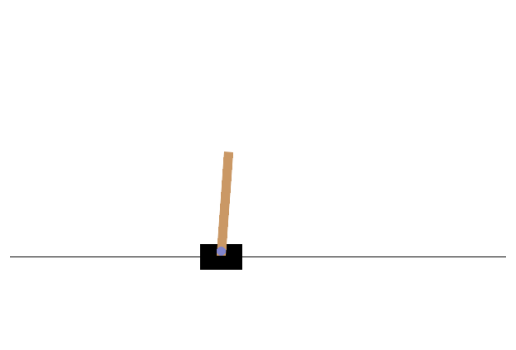

In [11]:
cp_classical_ppo.evaluate()

In [12]:
# 2. Qubit PPO
cp_config["actor_intermediate_dim"] = 3 # QNN Layers
mode = "qubit"
train = True # ~ 3 min if True

with MemoryTracker() as cp_qubit_stats:
    cp_qubit_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorQubitNN, 
        CriticClass=CriticNN, 
        env=cartpole_env,
        env_name=env_name,
        env_config=cp_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=cp_classical_stats
        )

    if train:
        qrl_results = cp_qubit_ppo.run()
    else:
       load_weights(results_folder, cp_qubit_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


PPO training

Episode 20: mean reward = 26.63 (0:00:04.718046)

Episode 40: mean reward = 22.10 (0:00:04.876139)

Episode 60: mean reward = 35.50 (0:00:05.482453)

Episode 80: mean reward = 60.60 (0:00:07.299500)

Episode 100: mean reward = 174.80 (0:00:14.598871)

Episode 120: mean reward = 178.10 (0:00:15.225224)

Episode 140: mean reward = 263.30 (0:00:18.628581)

Episode 160: mean reward = 255.70 (0:00:19.767642)

Episode 180: mean reward = 177.85 (0:00:15.027497)

Episode 200: mean reward = 419.50 (0:00:29.515640)

Episode 220: mean reward = 293.75 (0:00:22.226538)

Episode 240: mean reward = 446.85 (0:00:31.094958)

Total training time: 0:03:20.448592


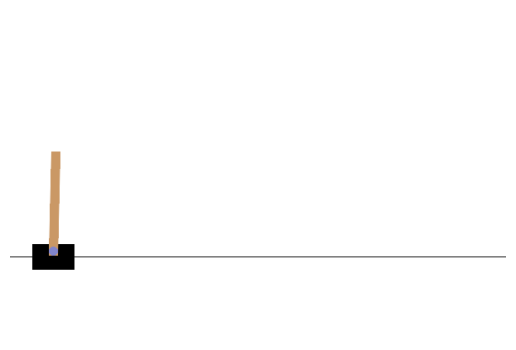

In [13]:
cp_qubit_ppo.evaluate()

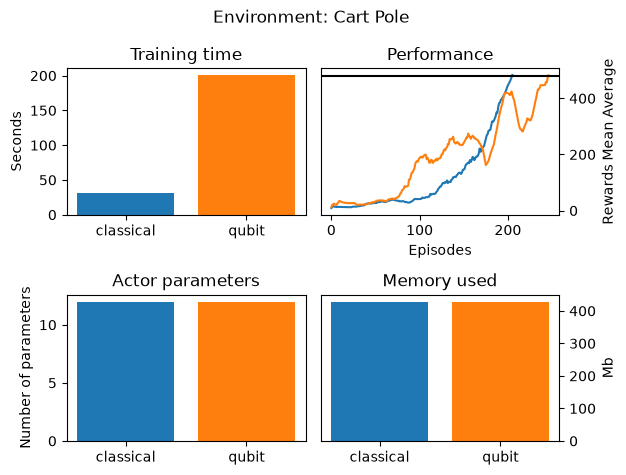

In [14]:
plot_results(env_name, qrl_results.get(env_name, {}), cp_config["mean_reward_stop"])

## 7 - Conclusions
___

The models were prepared so that they'd have the same number of parameters. The amount of memory used is also similar.

Both methods reached the expected performance, though the Qubit-based method took a bit more episodes to reach it in this particular instance. It has been the case with other seeds that the Qubit-based PPO took less episodes than the classical one. Its training time is always longer however. This is probably due to the fact that the quantum circuit is simulated. 

It is not expected that the Qubit-based model would outclass the classical one on such a simple problem, but it is interesting to see how easy it was to implement and integrate into PyTorch with PennyLane.

## 8 - Follow-ups
___

You can play around with the configuration : for example, try using other values for the AE's bottleneck (ae_output_dim) or the actor_intermediate_dim to see how the training and results change.

In the [next notebook](QRL_experiment_2.ipynb), the same methods will be used on two other environments: the Lunar Lander and a custom Maze environment. The training times will be longer as these environment are slightly more complicated.